# Download data (skips if data is already there

In [1]:
%run scripts/download_data.py

Skipping part1.tar.gz; already exists at C:\Users\Jhert\Documents\Education\Courses\DL\Assignments\final_group_project\CS7643-Final-Project-Age-Estimation-From-Limited-Image-Data\data\raw\utkface\part1.tar.gz
Skipping part2.tar.gz; already exists at C:\Users\Jhert\Documents\Education\Courses\DL\Assignments\final_group_project\CS7643-Final-Project-Age-Estimation-From-Limited-Image-Data\data\raw\utkface\part2.tar.gz
Skipping part3.tar.gz; already exists at C:\Users\Jhert\Documents\Education\Courses\DL\Assignments\final_group_project\CS7643-Final-Project-Age-Estimation-From-Limited-Image-Data\data\raw\utkface\part3.tar.gz
Done.


# Unzip files  - skip if raw data directories already exist

In [2]:
import os

# Check if the folder is empty; if so, extract the files
if os.path.isdir("data/raw/utkface/part1"):
    print("Already extracted part1, skipping.")
else:
    !tar -xzf data/raw/utkface/part1.tar.gz -C data/raw/utkface

if os.path.isdir("data/raw/utkface/part2"):
    print("Already extracted part2, skipping.")
else:
    !tar -xzf data/raw/utkface/part2.tar.gz -C data/raw/utkface

if os.path.isdir("data/raw/utkface/part3"):
    print("Already extracted part3, skipping.")
else:
    !tar -xzf data/raw/utkface/part3.tar.gz -C data/raw/utkface


Already extracted part1, skipping.
Already extracted part2, skipping.
Already extracted part3, skipping.


# Preprocess data

In [3]:
%run scripts/preprocess_data.py

Reproducibility: Random seed set to 42
RAW_DATA_DIR exists: True
RAW_DATA_DIR path: data\raw\utkface
data\raw\utkface -> 3 files
data\raw\utkface\part1 -> 10137 files


data\raw\utkface\part2 -> 10719 files


data\raw\utkface\part3 -> 3253 files


Skipped samples: 5
Train: 19283 | Valid: 2410 | Test: 2411
Sample skipped: [('61_1_20170109142408075.jpg', 'invalid_filename'), ('61_3_20170109150557335.jpg', 'invalid_filename'), ('39_1_20170116174525125.jpg', 'invalid_filename'), ('53__0_20170116184028385.jpg', 'invalid_filename'), ('.DS_Store', 'invalid_filename')]

[train] age statistics (n=19283)
  min=1  max=116  mean=33.05  median=29.0  std=20.11

[val] age statistics (n=2410)
  min=1  max=116  mean=33.11  median=29.0  std=20.22

[test] age statistics (n=2411)
  min=1  max=116  mean=32.96  median=29.0  std=20.31


# Print selected config file

In [4]:
from pathlib import Path

print(Path("configs/linear_regression_pretrained_feature_extractor_20epoch.yaml").read_text())

# Config file for ResNet18 pretrained on ImageNet, used as a frozen feature extractor for linear regression.
# This run keeps a distinct experiment name so it does not overwrite the 10-epoch baseline outputs.

experiment_name: "linear_regression_pretrained_feature_extractor_20epoch"
model_name: "linear"  # linear, mlp, or mlp_dropout
seed: 42
pretrained: True
freeze_backbone: True     # Whether to fine-tune the pretrained model or just use it as a feature extractor
task: "regression"  # regression or classification
metric: "mae"       # mse for regression, accuracy for classification

# Data parameters
batch_size: 32
num_workers: 4
image_size: 224

# Training parameters
epochs: 20
learning_rate: 0.001
optimizer: "Adam"
#loss_function: "MSELoss" unused since we set it in train.py based on task
save_best: True

# MLP + Dropout
dropout: 0.2



# Train pretrained frozen ResNet18 feature extractor

Reproducibility: Random seed set to 42
Pipeline Initialized. Loading data and model...


Setup complete! Ready to begin training epochs.


  0%|          | 0/602 [00:00<?, ?it/s]

  0%|          | 0/602 [00:10<?, ?it/s, loss=1.24e+3]

  0%|          | 1/602 [00:10<1:42:07, 10.20s/it, loss=1.24e+3]

...

 95%|#########4| 72/76 [00:13<00:00, 20.98it/s, loss=176]

 95%|#########4| 72/76 [00:13<00:00, 20.98it/s, loss=177]

 95%|#########4| 72/76 [00:13<00:00, 20.98it/s, loss=177]

100%|##########| 76/76 [00:13<00:00,  5.48it/s, loss=177]

Epoch [20/20] Train Loss: 174.4906, Train MAE: 10.1373, Train MSE: 174.4906, Train Acc@3: 0.2012, Train Acc@5: 0.3260 | Val Loss: 176.5015, Val MAE: 10.0768, Val MSE: 176.5015, Val Acc@3: 0.2087, Val Acc@5: 0.3270, Val MAE: 10.0768
Saved model with MAE = 10.0657
Saved training stats history to C:\Users\Jhert\Documents\Education\Courses\DL\Assignments\final_group_project\CS7643-Final-Project-Age-Estimation-From-Limited-Image-Data\outputs\stats_history_linear_regression_pretrained_feature_extractor_20epoch.npy
Training completely finished! Best Val Loss: 177.8265, Best Val MAE: 10.0657


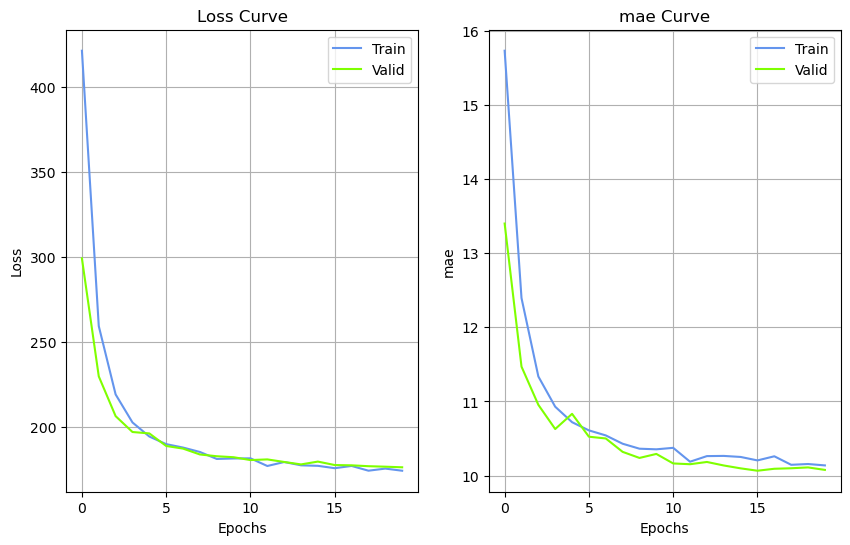

In [5]:
%run scripts/train.py --config configs/linear_regression_pretrained_feature_extractor_20epoch.yaml

# Evaluate pretrained frozen ResNet18 feature extractor

In [6]:
%run scripts/evaluate.py --config configs/linear_regression_pretrained_feature_extractor_20epoch.yaml

Reproducibility: Random seed set to 42
Configuration loaded. Loading data and model...
Loading model from checkpoint: C:\Users\Jhert\Documents\Education\Courses\DL\Assignments\final_group_project\CS7643-Final-Project-Age-Estimation-From-Limited-Image-Data\outputs\checkpoint_linear_regression_pretrained_feature_extractor_20epoch.pth


  0%|          | 0/76 [00:00<?, ?it/s]

  0%|          | 0/76 [00:09<?, ?it/s, loss=107]

  1%|1         | 1/76 [00:09<11:15,  9.01s/it, loss=107]

  1%|1         | 1/76 [00:09<11:15,  9.01s/it, loss=143]

...

 96%|#########6| 73/76 [00:12<00:00, 21.46it/s, loss=181]

 96%|#########6| 73/76 [00:12<00:00, 21.46it/s, loss=181]

100%|##########| 76/76 [00:12<00:00, 19.33it/s, loss=181]

100%|##########| 76/76 [00:12<00:00,  5.98it/s, loss=181]


Evaluation Metrics — linear_regression_pretrained_feature_extractor_20epoch
+--------+----------+
| Metric |    Value |
+--------+----------+
| MAE    |  10.2674 |
| MSE    | 181.2371 |
| Acc@3  |   0.2003 |
| Acc@5  |   0.3368 |
+--------+----------+
